In [ ]:
!pip install roboflow
!pip install ultralytics
!pip install tensorflow


  Using cached roboflow-1.2.11-py3-none-any.whl.metadata (9.7 kB)
  Using cached idna-3.7-py3-none-any.whl.metadata (9.9 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached kiwisolver-1.4.9-cp310-cp310-macosx_11_0_arm64.whl.metadata (6.3 kB)
  Using cached matplotlib-3.10.8-cp310-cp310-macosx_11_0_arm64.whl.metadata (52 kB)
  Using cached opencv_python_headless-4.10.0.84-cp37-abi3-macosx_11_0_arm64.whl.metadata (20 kB)
  Using cached python_dotenv-1.2.1-py3-none-any.whl.metadata (25 kB)
  Using cached tqdm-4.67.1-py3-none-any.whl.metadata (57 kB)
  Using cached pyyaml-6.0.3-cp310-cp310-macosx_11_0_arm64.whl.metadata (2.4 kB)
  Using cached requests_toolbelt-1.0.0-py2.py3-none-any.whl.metadata (14 kB)
  Using cached filetype-1.2.0-py2.py3-none-any.whl.metadata (6.5 kB)
  Using cached contourpy-1.3.2-cp310-cp310-macosx_11_0_arm64.whl.metadata (5.5 kB)
  Using cached fonttools-4.61.1-cp310-cp310-macosx_10_9_universal2.whl.metadata (114 kB)
  Using cached pyp

In [ ]:
# Import Roboflow and download the dataset
# Replace with your own API key

from roboflow import Roboflow
rf = Roboflow(api_key="vTzew3AtkBTfLFYTGrvN")
project = rf.workspace("koteitan").project("book-spine-detection-2cci9")
version = project.version(2)
dataset = version.download("yolov11")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to book-spine-detection-2 in yolov11:: 100%|██████████| 18600/18600 [00:03<00:00, 5760.90it/s]


In [4]:
dataset.location

'/Users/tannu/Capstone Projects/ShelfScanner/book-spine-detection-2'

In [ ]:
!yolo task=detect mode=train model=yolov11n.pt data={dataset.location}/data.yaml epochs=100 imgsz=640 batch=12

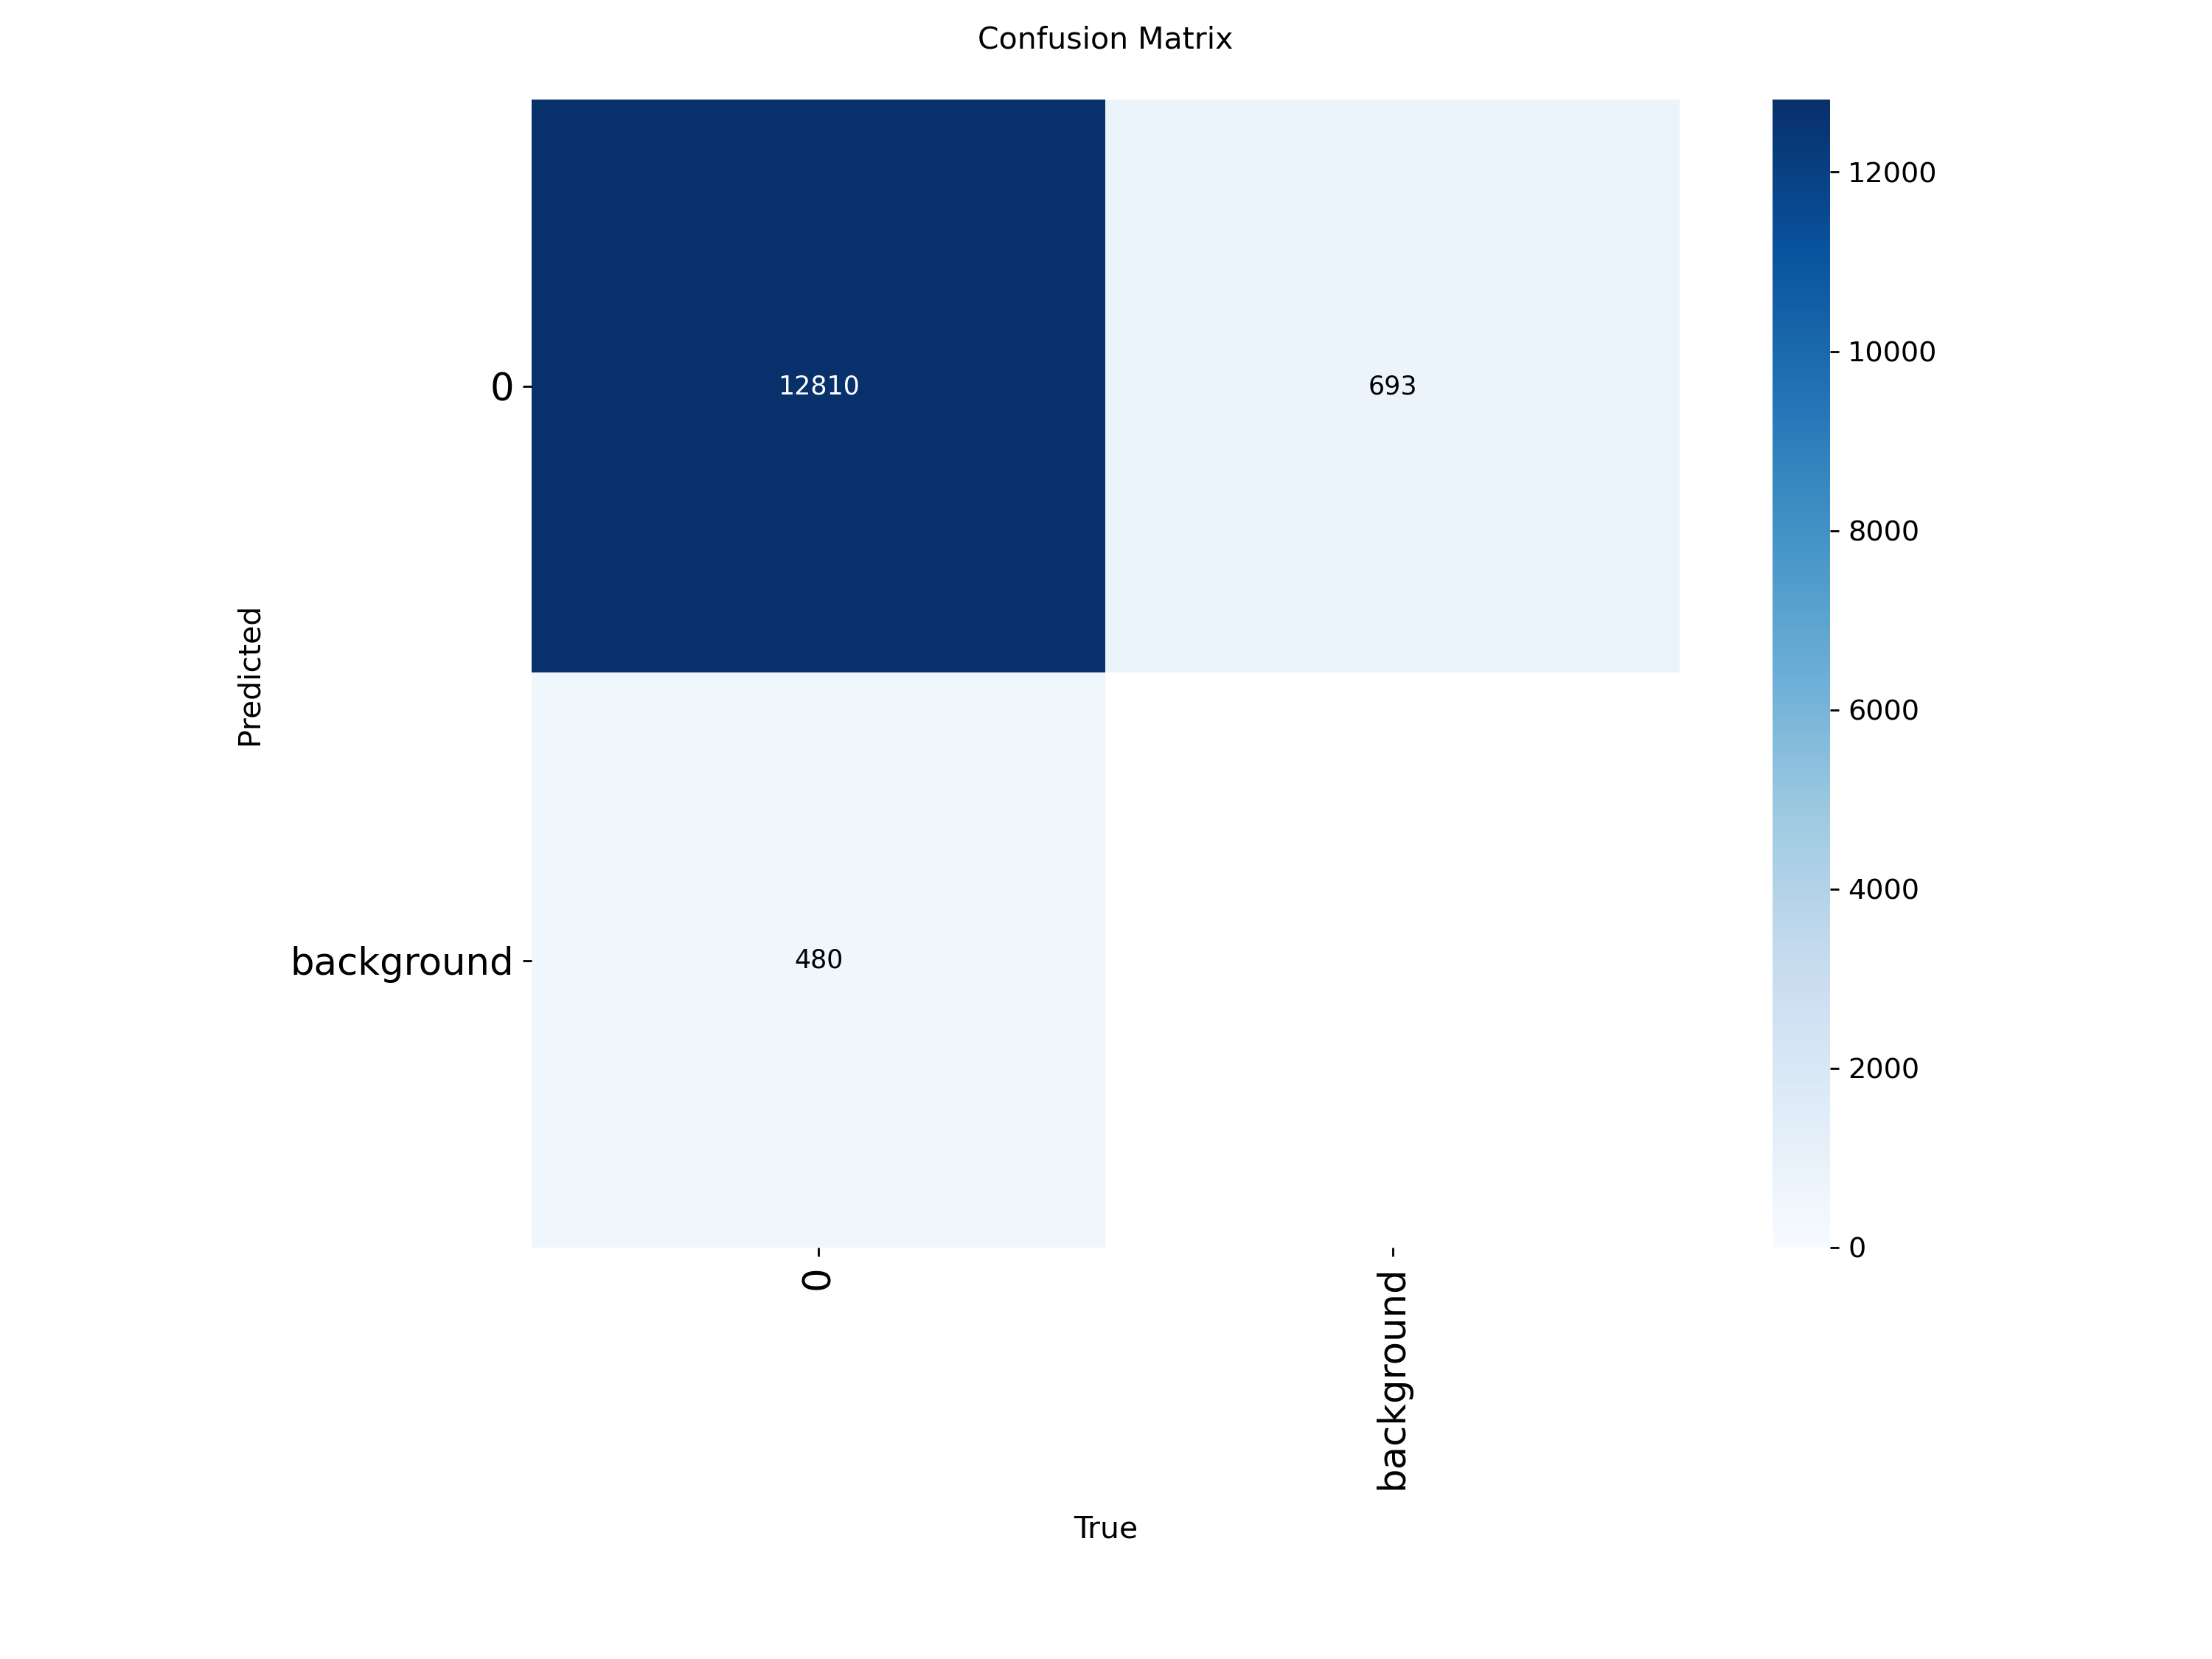

In [3]:
from IPython.display import Image as IPyImage
IPyImage(filename='runs/detect/train/confusion_matrix.png', width = 500)

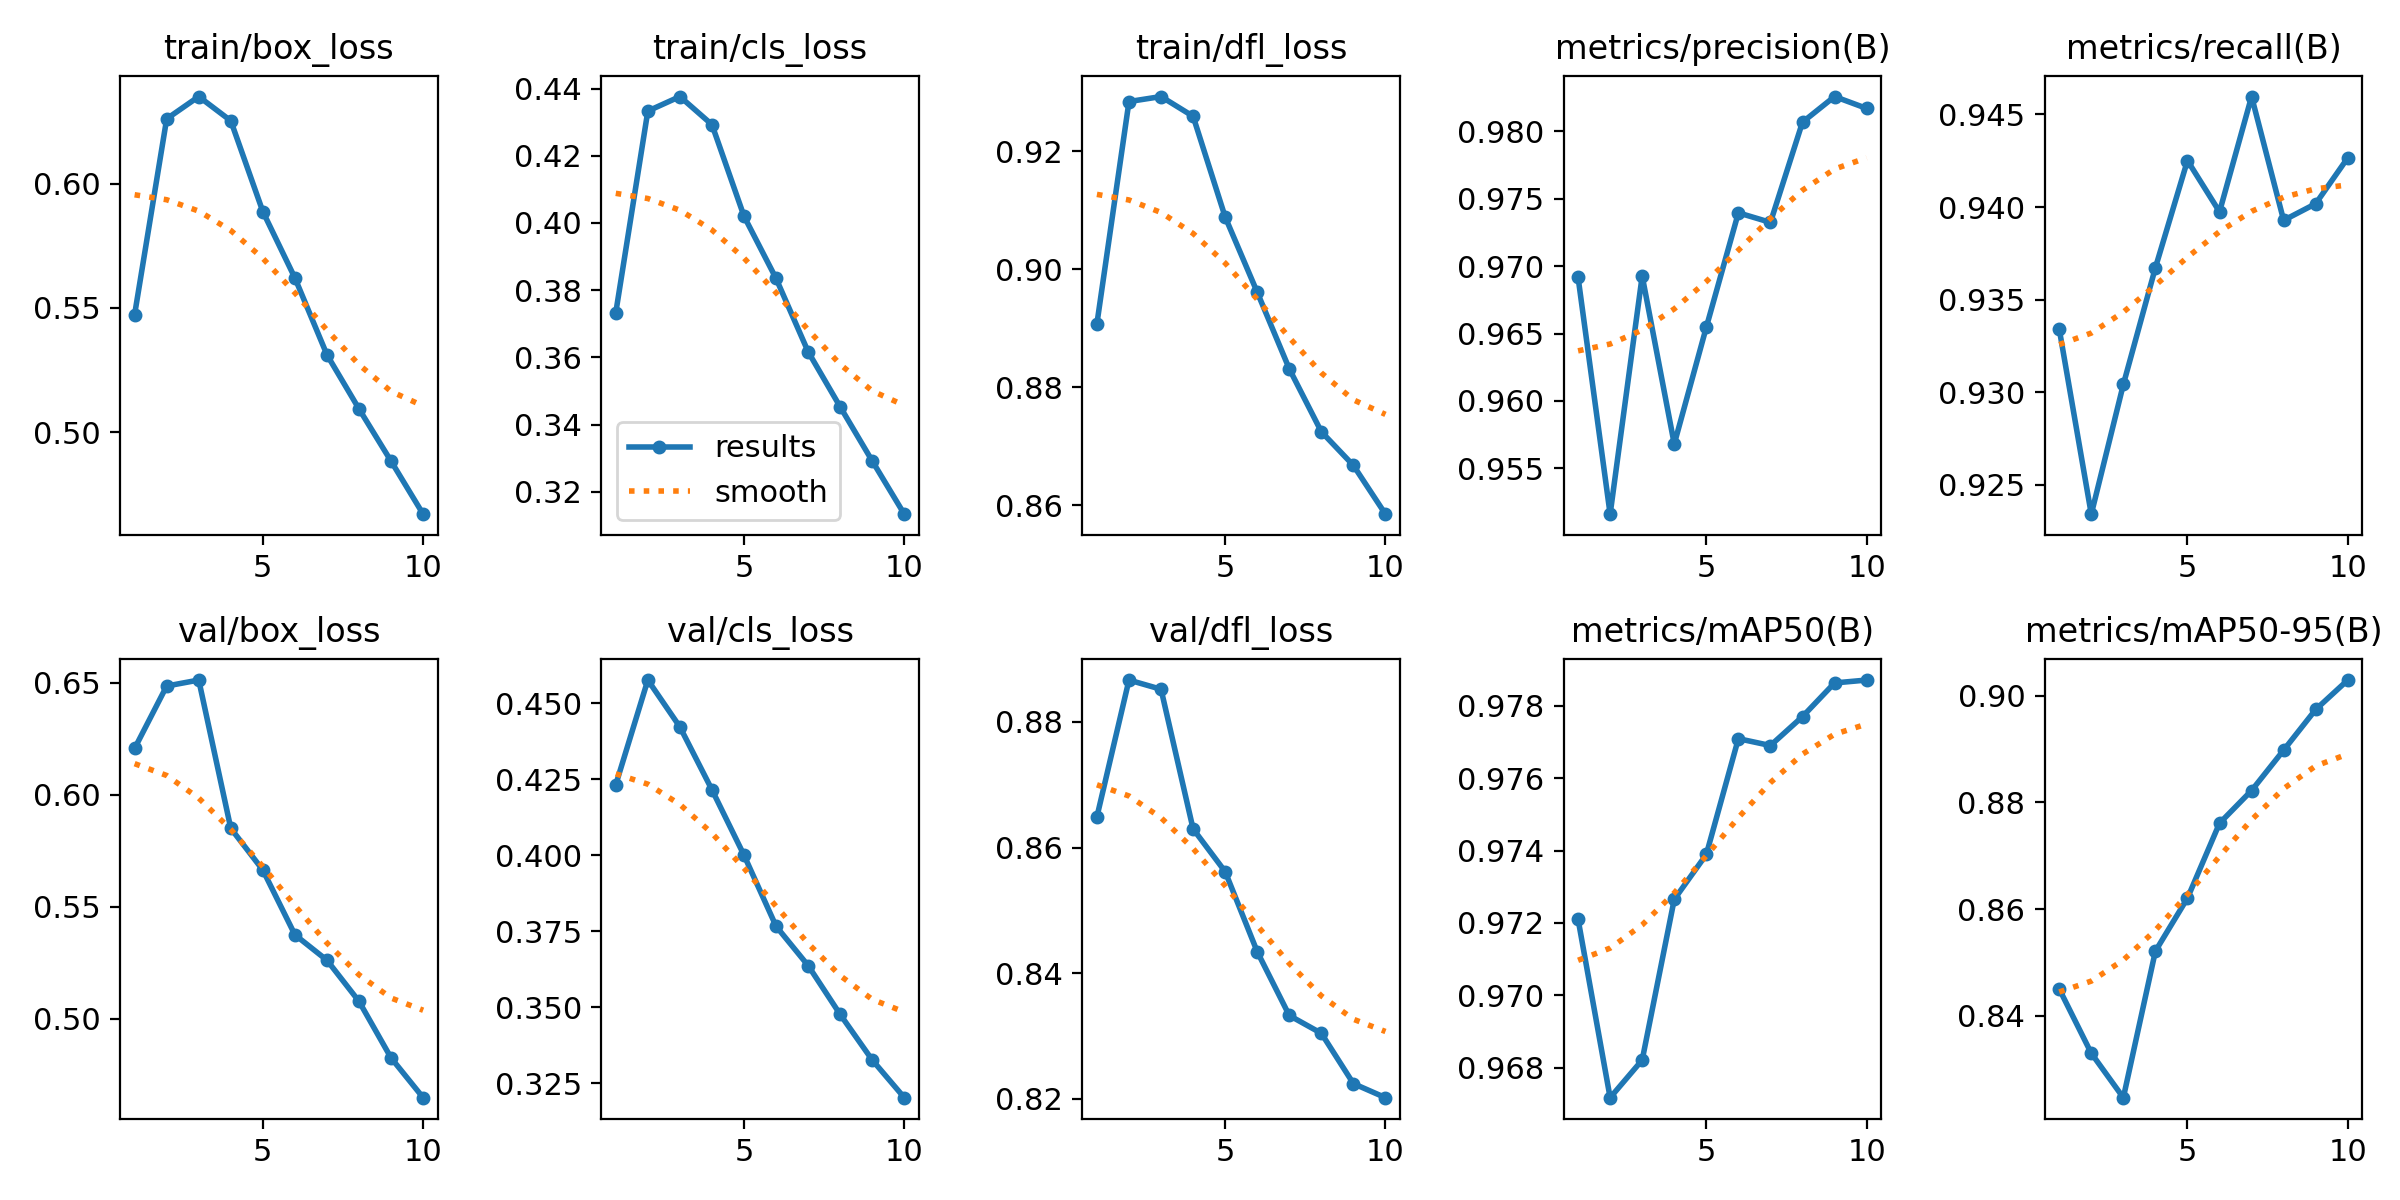

In [5]:
IPyImage(filename='runs/detect/train/results.png', width = 800)

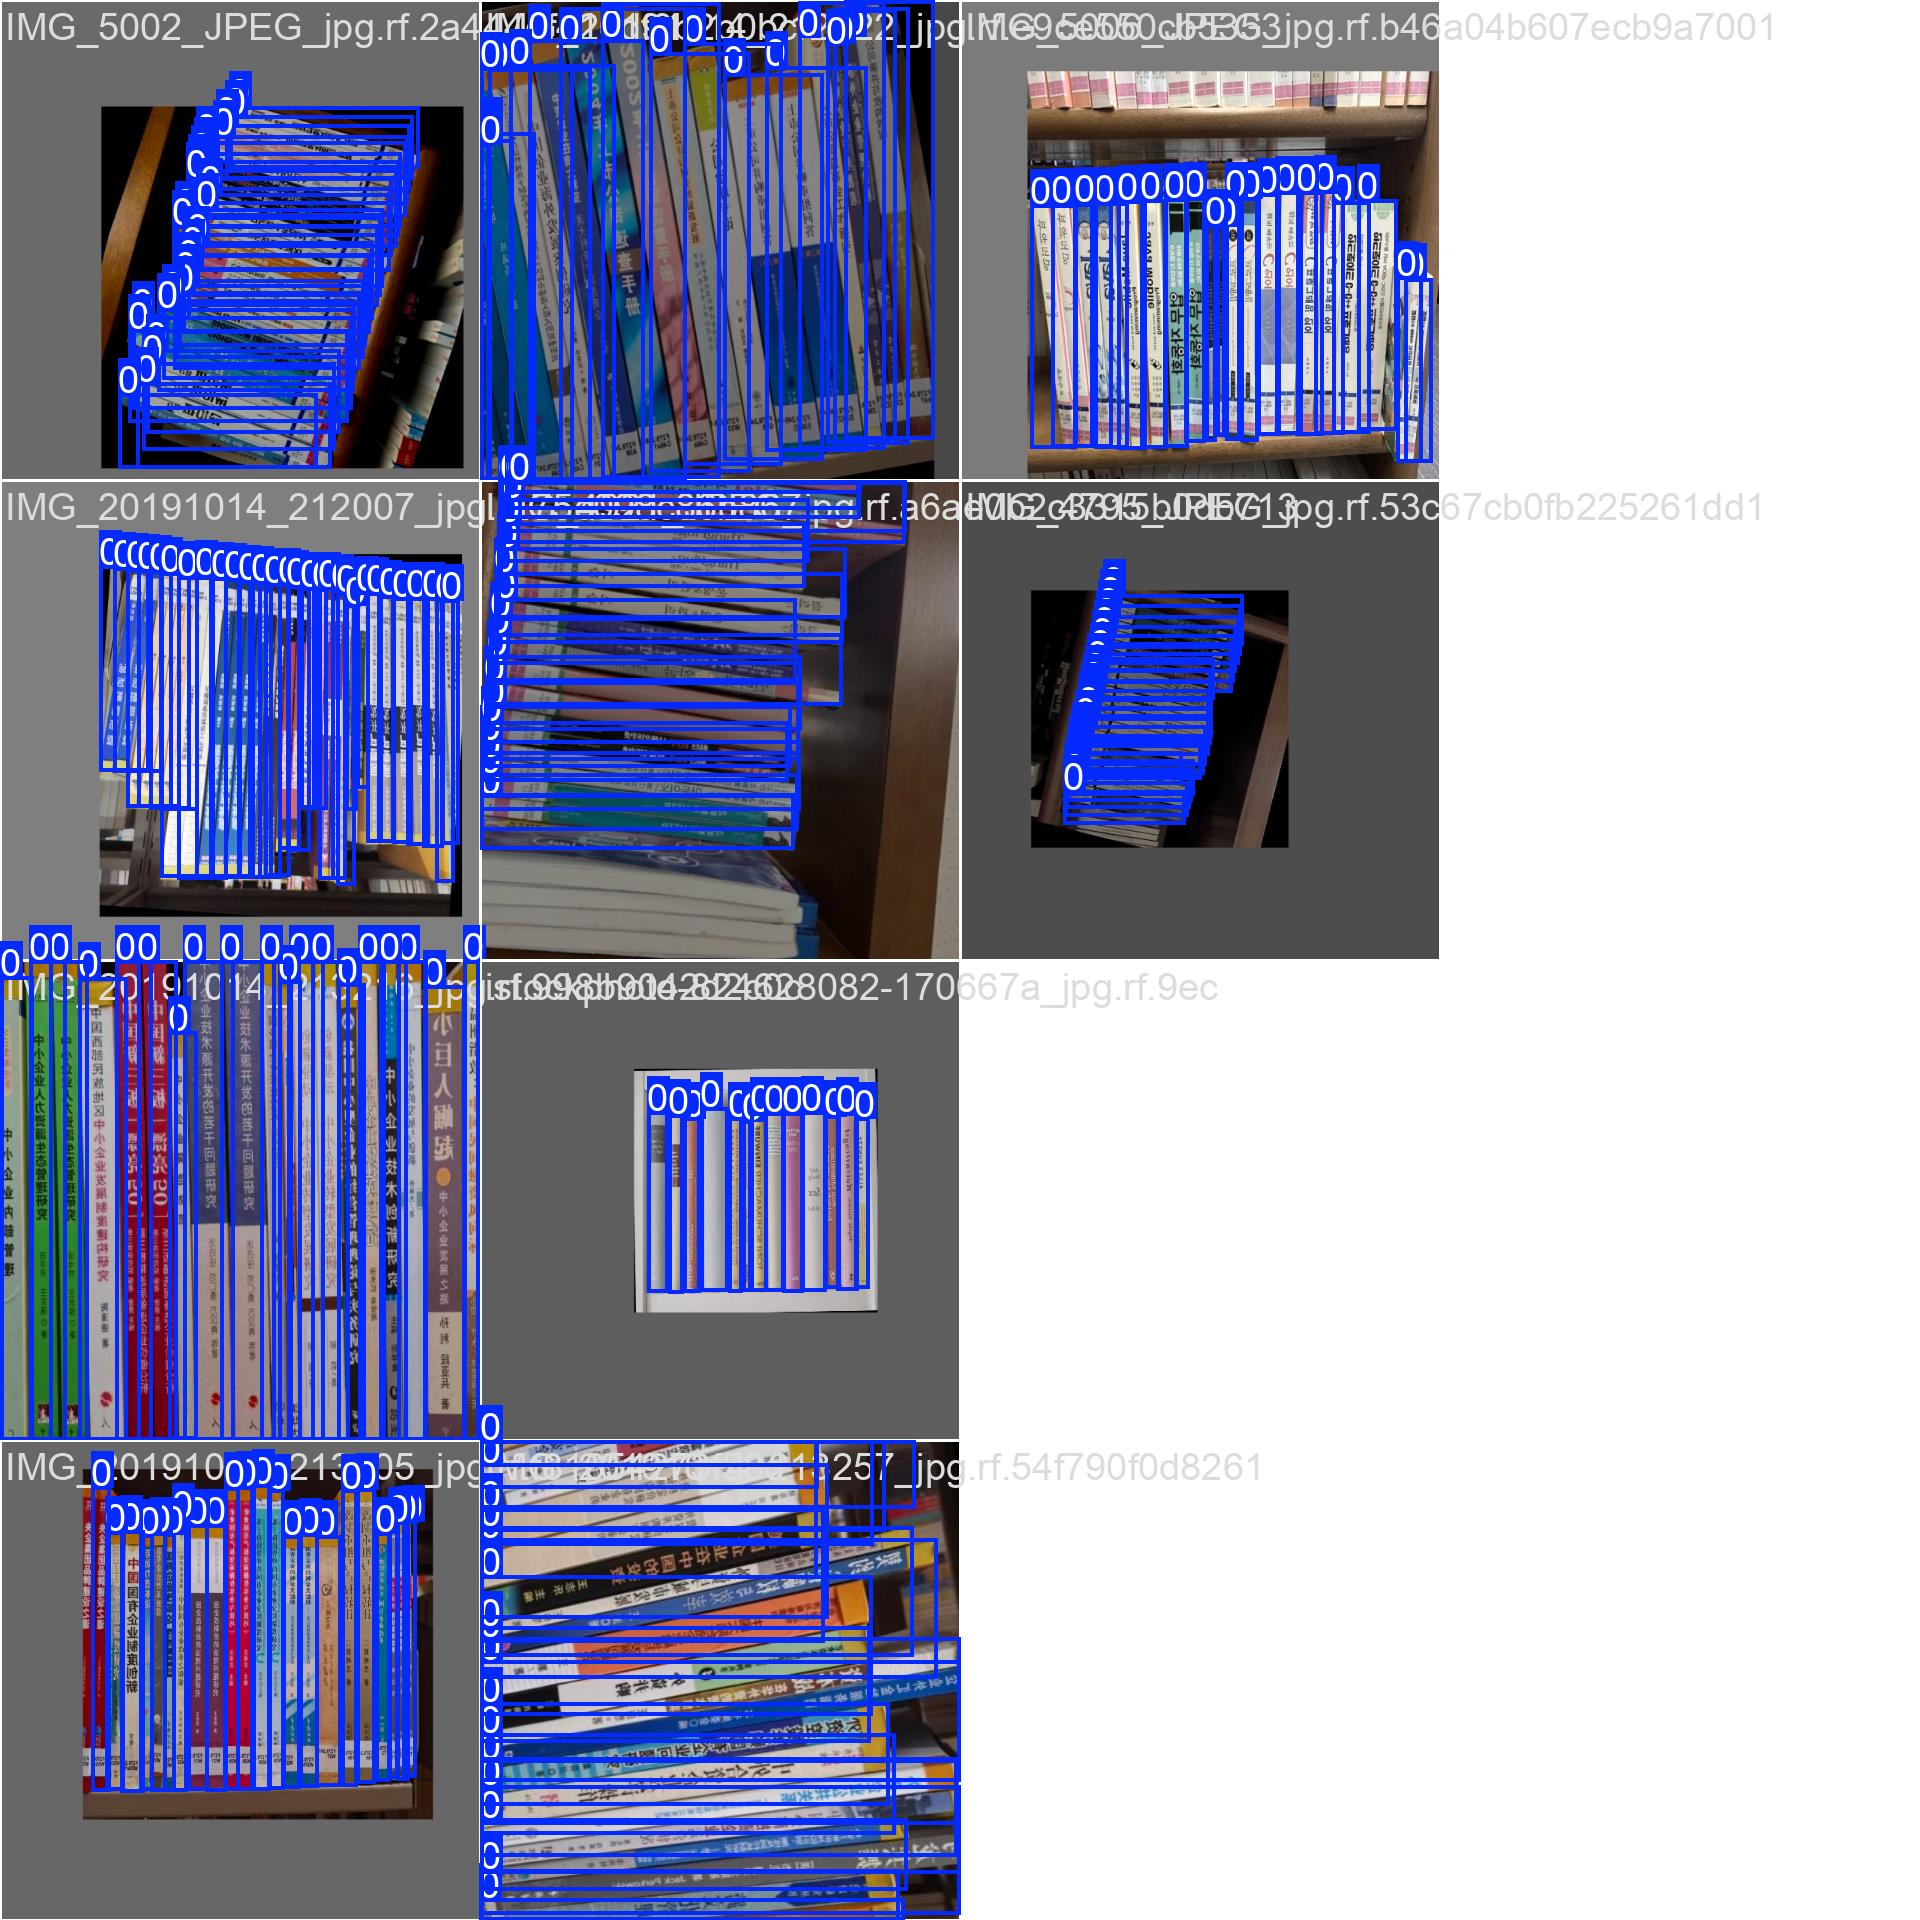

In [8]:
IPyImage(filename='runs/detect/train/train_batch2.jpg', width = 800)

In [4]:
!yolo export model=runs/detect/train/weights/best.pt format=tflite

Ultralytics 8.3.240 🚀 Python-3.10.19 torch-2.9.1 CPU (Apple M2 Pro)
YOLO11x summary (fused): 190 layers, 56,828,179 parameters, 0 gradients, 194.4 GFLOPs

PyTorch: starting from 'runs/detect/train/weights/best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 5, 8400) (109.1 MB)

TensorFlow SavedModel: starting export with tensorflow 2.19.1...

ONNX: starting export with onnx 1.20.0 opset 22...
/Users/tannu/tools/miniconda3/envs/myenv/lib/python3.10/site-packages/torch/onnx/_internal/torchscript_exporter/utils.py:1447: OnnxExporterWarning: Exporting to ONNX opset version 22 is not supported. by 'torch.onnx.export()'. The highest opset version supported is 20. To use a newer opset version, consider 'torch.onnx.export(..., dynamo=True)'. 
  warnings.warn(
ONNX: slimming with onnxslim 0.1.80...
ONNX: export success ✅ 3.5s, saved as 'runs/detect/train/weights/best.onnx' (217.2 MB)
TensorFlow SavedModel: starting TFLite export with onnx2tf 1.28.7...
Saved artifact at 'runs/

In [ ]:
# Recommended export for Mobile Flutter
!yolo export model=runs/detect/book-train3/weights/best.pt format=tflite imgsz=640 int8=False nms=False

Ultralytics 8.3.240 🚀 Python-3.10.19 torch-2.9.1 CPU (Apple M2 Pro)
YOLO11x summary (fused): 190 layers, 56,828,179 parameters, 0 gradients, 194.4 GFLOPs

PyTorch: starting from 'runs/detect/book-train4/weights/best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 5, 8400) (109.1 MB)

TensorFlow SavedModel: starting export with tensorflow 2.19.1...

ONNX: starting export with onnx 1.20.0 opset 22...
/Users/tannu/tools/miniconda3/envs/myenv/lib/python3.10/site-packages/torch/onnx/_internal/torchscript_exporter/utils.py:1447: OnnxExporterWarning: Exporting to ONNX opset version 22 is not supported. by 'torch.onnx.export()'. The highest opset version supported is 20. To use a newer opset version, consider 'torch.onnx.export(..., dynamo=True)'. 
  warnings.warn(
ONNX: slimming with onnxslim 0.1.80...
ONNX: export success ✅ 2.5s, saved as 'runs/detect/book-train4/weights/best.onnx' (217.2 MB)
TensorFlow SavedModel: starting TFLite export with onnx2tf 1.28.7...
Saved artifa